In [487]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_parquet('../data/processed/dados_eda.parquet')

# Primeiras linhas para garantir que está tudo certo
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,contatado_antes,faixa_etaria,faixa_campaign
0,56,housemaid,married,basic.4y,0,0,0,telephone,may,mon,...,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0,51_65,1
1,57,services,married,high.school,0,0,0,telephone,may,mon,...,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0,51_65,1
2,37,services,married,high.school,0,1,0,telephone,may,mon,...,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0,36_50,1
3,40,admin.,married,basic.6y,0,0,0,telephone,may,mon,...,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0,36_50,1
4,56,services,married,high.school,0,0,1,telephone,may,mon,...,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0,51_65,1


In [488]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41174 entries, 0 to 41173
Data columns (total 24 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   age              41174 non-null  int64   
 1   job              41174 non-null  category
 2   marital          41174 non-null  category
 3   education        41174 non-null  category
 4   default          41174 non-null  int64   
 5   housing          41174 non-null  int64   
 6   loan             41174 non-null  int64   
 7   contact          41174 non-null  category
 8   month            41174 non-null  category
 9   day_of_week      41174 non-null  category
 10  duration         41174 non-null  int64   
 11  campaign         41174 non-null  int64   
 12  pdays            41174 non-null  int64   
 13  previous         41174 non-null  int64   
 14  poutcome         41174 non-null  category
 15  emp.var.rate     41174 non-null  float64 
 16  cons.price.idx   41174 non-null  float64

In [489]:
df.describe()

,age,default,housing,loan,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,contatado_antes
count,41174.000000,41174.000000,41174.000000,41174.000000,41174.000000,41174.000000,41174.000000,41174.000000,41174.000000,41174.000000,41174.000000,41174.000000,41174.000000,41174.000000,41174.000000
mean,40.023583,0.000073,0.547919,0.151746,258.323627,2.567956,0.221305,0.173022,0.081865,93.575713,-40.503070,3.621231,5167.032805,0.112668,0.036795
std,10.420578,0.008536,0.497705,0.358779,259.309058,2.770364,1.349097,0.494975,1.570899,0.578849,4.627877,1.734456,72.252395,0.316191,0.188261
min,17.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000,0.000000
25%,32.000000,0.000000,0.000000,0.000000,102.000000,1.000000,0.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000,0.000000,0.000000
50%,38.000000,0.000000,1.000000,0.000000,180.000000,2.000000,0.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000,0.000000,0.000000
75%,47.000000,0.000000,1.000000,0.000000,319.000000,3.000000,0.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,0.000000,0.000000
max,98.000000,1.000000,1.000000,1.000000,4918.000000,56.000000,27.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,1.000000,1.000000


In [490]:
df.describe(include=["category"])

,job,marital,education,contact,month,day_of_week,poutcome,faixa_etaria,faixa_campaign
count,41174,41174,41174,41174,41174,41174,41174,41174,41174
unique,11,3,7,2,10,5,3,5,4
top,admin.,married,university.degree,cellular,may,thu,nonexistent,36_50,1
freq,10748,24999,13893,26134,13766,8617,35549,17489,17632


In [491]:
df["y"].value_counts()

y
0    36535
1     4639
Name: count, dtype: int64

In [492]:
df["y"].value_counts(normalize=True) * 100

y
0    88.733181
1    11.266819
Name: proportion, dtype: float64

In [493]:
taxa_conversao_job = df.groupby("job")["y"].mean().sort_values(ascending=False) * 100
taxa_conversao_job

C:\Users\yangi\AppData\Local\Temp\ipykernel_11620\4042175849.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  taxa_conversao_job = df.groupby("job")["y"].mean().sort_values(ascending=False) * 100


job
student          31.428571
retired          25.261932
unemployed       14.201183
admin.           12.914031
management       11.217510
technician       10.832468
self-employed    10.485574
housemaid        10.000000
entrepreneur      8.516484
services          8.142173
blue-collar       6.895806
Name: y, dtype: float64

In [494]:
taxa_conversao_idade = df.groupby("faixa_etaria")["y"].mean().sort_values(ascending=False) * 100
taxa_conversao_idade

C:\Users\yangi\AppData\Local\Temp\ipykernel_11620\782991148.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  taxa_conversao_idade = df.groupby("faixa_etaria")["y"].mean().sort_values(ascending=False) * 100


faixa_etaria
acima_65    46.925566
ate_25      20.960961
51_65       12.075011
26_35       11.722698
36_50        8.393848
Name: y, dtype: float64

In [495]:
# Seleciona apenas as colunas numéricas
colunas_numericas = df.select_dtypes(include=['number'])

# Calcula a matriz de correlação
matriz_correlacao = colunas_numericas.corr()

# Foca apenas na correlação das variáveis com a variável alvo 'y'
correlacao_com_alvo = matriz_correlacao['y'].sort_values(ascending=False)
correlacao_com_alvo

y                  1.000000
duration           0.405292
contatado_antes    0.324908
pdays              0.267113
previous           0.230197
cons.conf.idx      0.054819
age                0.030389
housing            0.011144
default           -0.003042
loan              -0.004486
campaign          -0.066371
cons.price.idx    -0.136131
emp.var.rate      -0.298281
euribor3m         -0.307733
nr.employed       -0.354663
Name: y, dtype: float64

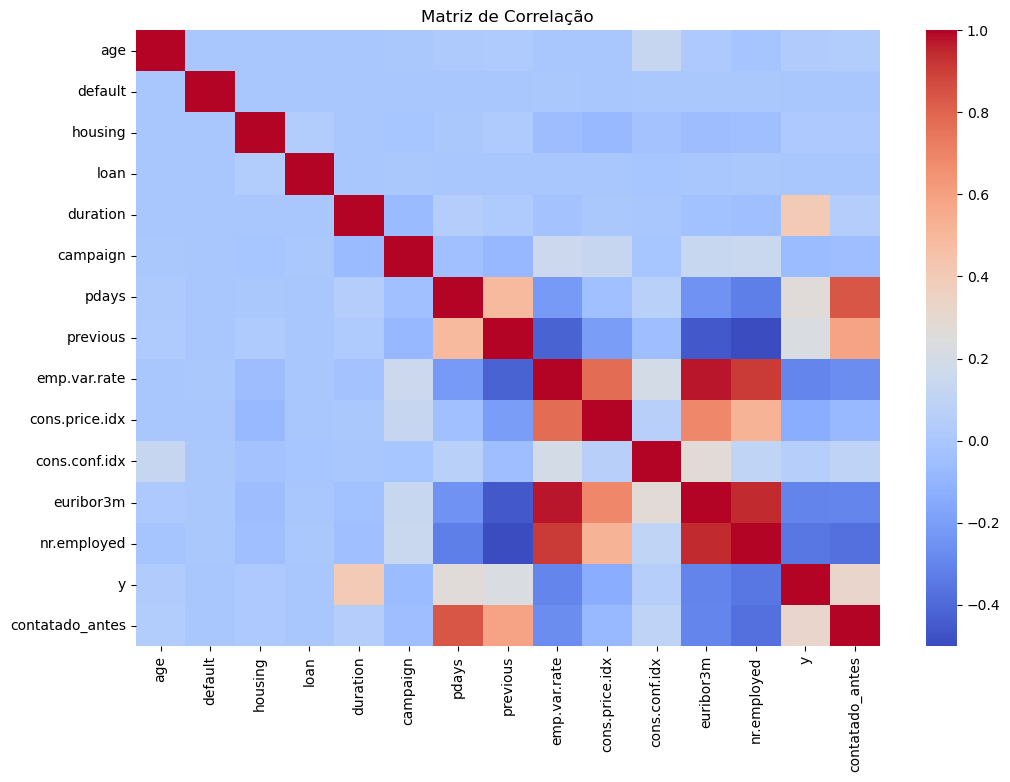

In [496]:
# Gráfico da correlação (Heatmap)
plt.figure(figsize=(12, 8))
sns.heatmap(matriz_correlacao, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação')
plt.show()

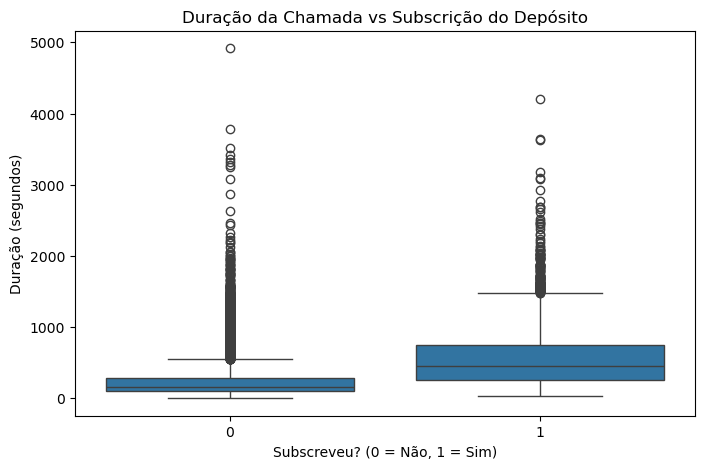

In [497]:
# Distribuição da duração da chamada para quem comprou vs não comprou
plt.figure(figsize=(8, 5))
sns.boxplot(x='y', y='duration', data=df)
plt.title('Duração da Chamada vs Subscrição do Depósito')
plt.xlabel('Subscreveu? (0 = Não, 1 = Sim)')
plt.ylabel('Duração (segundos)')
plt.show()

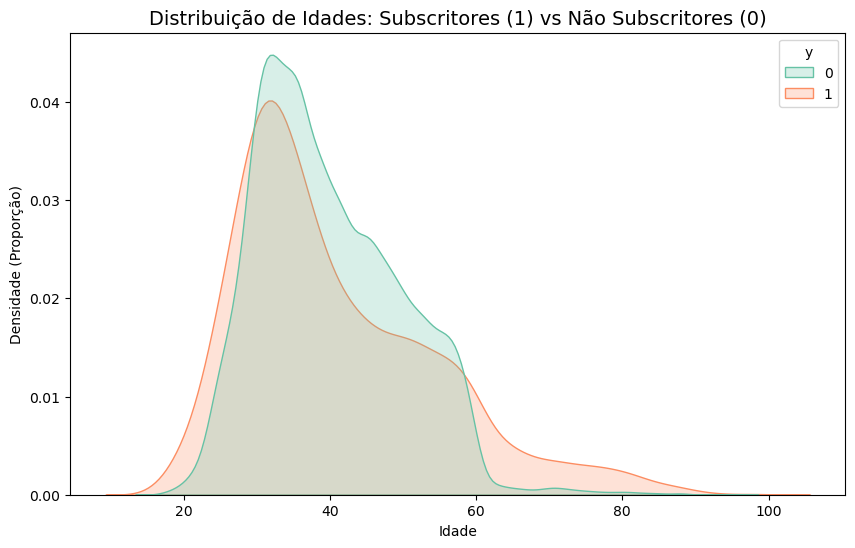

In [498]:
plt.figure(figsize=(10, 6))
# Usamos common_norm=False para ver a proporção de cada grupo independentemente do seu tamanho total
sns.kdeplot(data=df, x='age', hue='y', fill=True, common_norm=False, palette='Set2')
plt.title('Distribuição de Idades: Subscritores (1) vs Não Subscritores (0)', fontsize=14)
plt.xlabel('Idade')
plt.ylabel('Densidade (Proporção)')
plt.show()

C:\Users\yangi\AppData\Local\Temp\ipykernel_11620\590437625.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  taxa_mes = df.groupby('month')['y'].mean().reset_index()
C:\Users\yangi\AppData\Local\Temp\ipykernel_11620\590437625.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=taxa_mes, x='month', y='y', palette='viridis')


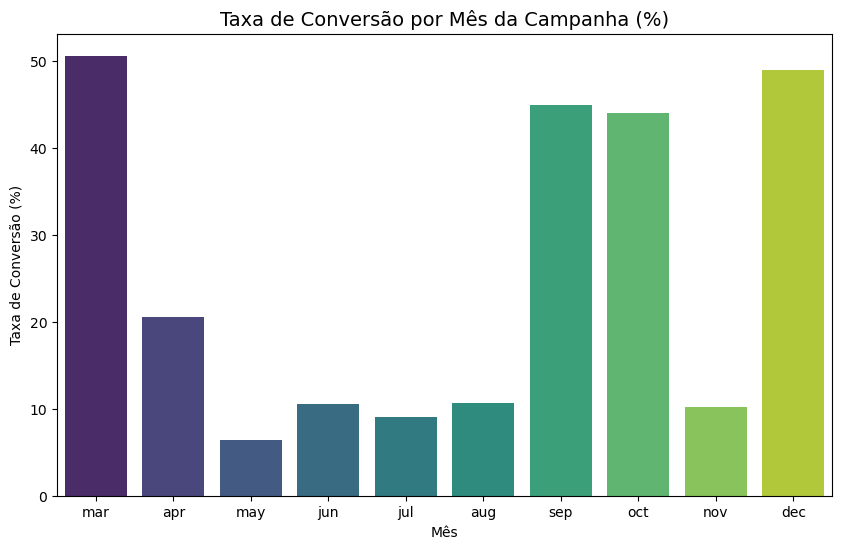

In [499]:
taxa_mes = df.groupby('month')['y'].mean().reset_index()
taxa_mes['y'] = taxa_mes['y'] * 100

# Ordenar os meses cronologicamente para fazer sentido visualmente
meses_ordem = ['mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
taxa_mes['month'] = pd.Categorical(taxa_mes['month'], categories=meses_ordem, ordered=True)
taxa_mes = taxa_mes.sort_values('month')

plt.figure(figsize=(10, 6))
sns.barplot(data=taxa_mes, x='month', y='y', palette='viridis')
plt.title('Taxa de Conversão por Mês da Campanha (%)', fontsize=14)
plt.xlabel('Mês')
plt.ylabel('Taxa de Conversão (%)')
plt.show()

C:\Users\yangi\AppData\Local\Temp\ipykernel_11620\4180275740.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='poutcome', y='y', palette='magma')


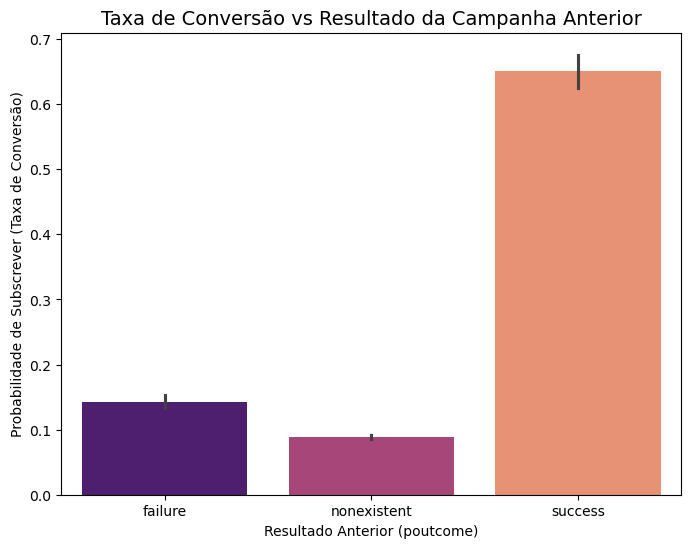

In [500]:
plt.figure(figsize=(8, 6))
# O sns.barplot por defeito já calcula a média (que é a nossa taxa de conversão)
sns.barplot(data=df, x='poutcome', y='y', palette='magma')
plt.title('Taxa de Conversão vs Resultado da Campanha Anterior', fontsize=14)
plt.xlabel('Resultado Anterior (poutcome)')
plt.ylabel('Probabilidade de Subscrever (Taxa de Conversão)')
plt.show()

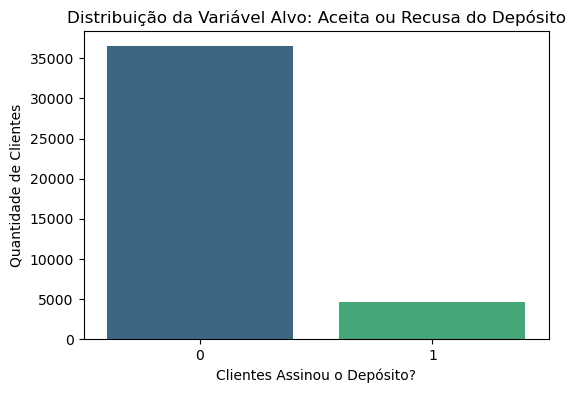

In [501]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='y', hue='y', palette='viridis', legend=False)
plt.title('Distribuição da Variável Alvo: Aceita ou Recusa do Depósito')
plt.xlabel('Clientes Assinou o Depósito?')
plt.ylabel('Quantidade de Clientes')
plt.show()

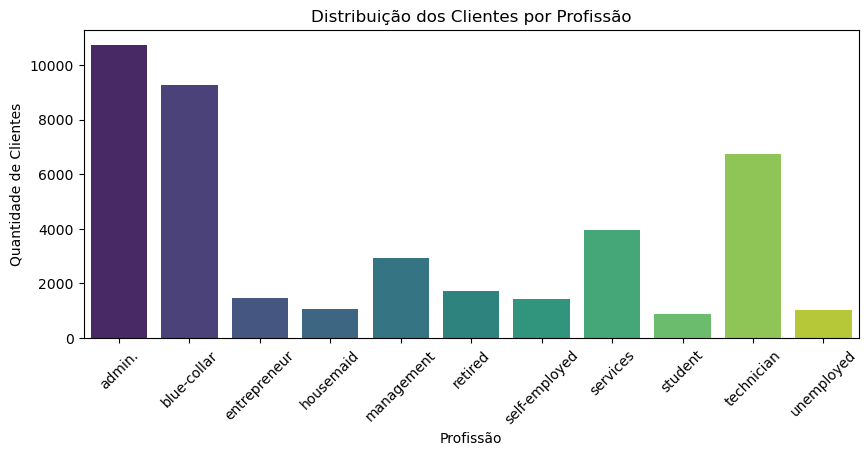

In [502]:
# Mostrar o perfil dos clientes
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x='job', hue='job', palette='viridis', legend=False)
plt.title('Distribuição dos Clientes por Profissão')
plt.xlabel('Profissão')
plt.ylabel('Quantidade de Clientes')
plt.xticks(rotation=45)
plt.show()

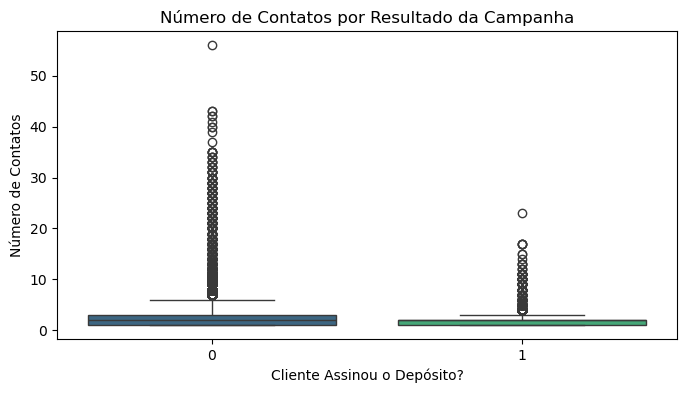

In [503]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x='y', y='campaign', hue='y', palette='viridis', legend=False)
plt.title('Número de Contatos por Resultado da Campanha')
plt.xlabel('Cliente Assinou o Depósito?')
plt.ylabel('Número de Contatos')
plt.show()

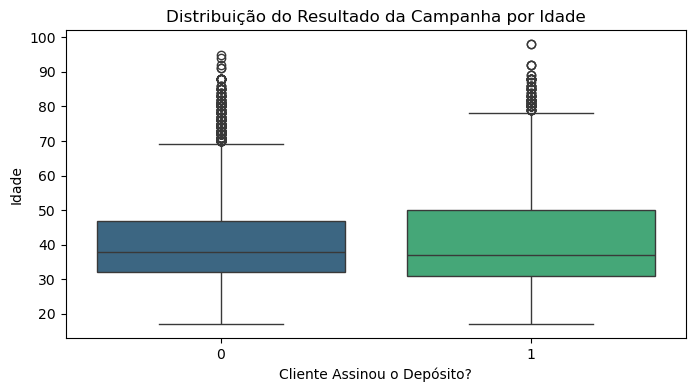

In [504]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x='y', y='age', hue='y', palette='viridis', legend=False)
plt.title('Distribuição do Resultado da Campanha por Idade')
plt.xlabel('Cliente Assinou o Depósito?')
plt.ylabel('Idade')
plt.show()